In [ ]:
# vis Band-pass filter

In [2]:
from pathlib import Path
import sys

# In scripts, use __file__; in notebooks, use current working directory
try:
    current_path = Path(__file__).resolve().parent
except NameError:
    current_path = Path.cwd().resolve()

# Go up until you find the project root where "src" exists
for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists():
        project_root = parent
        break
else:
    raise FileNotFoundError("Project root not found. No parent folder contains 'src'.")

# Add project root to PYTHONPATH if not already there
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)

# Now import works
from src.modules import tools_EEG_Preprocess as TEEG_PR

Project root: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project


## visualiation of band pass before and after

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


def plot_psd_two_npz_with_lines(
    npz_path_1: str,
    npz_path_2: str,
    channel: int = 0,
    nperseg_sec: float = 4.0,
    overlap_frac: float = 0.5,
    xlim: tuple[float, float] | None = (0, 60),
    use_semilogy: bool = True,
    figsize: tuple[int, int] = (10, 5),
    strict_checks: bool = False,
):
    """
    Plot Welch PSD from two EEG NPZ files in the same figure.
    Adds vertical dashed lines at 5 Hz and 48 Hz.
    """

    def _load_npz_signal(npz_path: str):
        data = np.load(npz_path, allow_pickle=True)

        if "signal" in data:
            sig = data["signal"]

            if sig.ndim != 2:
                raise ValueError(f"'signal' in {npz_path} is not 2D.")

            # Convert to (C, N) if it looks like (N, C)
            if sig.shape[0] > sig.shape[1]:
                sig = sig.T

            signal_key = "signal"
            channel_names = data["channels"] if "channels" in data else np.array(
                [f"ch_{i}" for i in range(sig.shape[0])]
            )

        elif "X" in data:
            sig = data["X"]

            if sig.ndim != 2:
                raise ValueError(f"'X' in {npz_path} is not 2D.")

            signal_key = "X"
            channel_names = data["channel_names"] if "channel_names" in data else np.array(
                [f"ch_{i}" for i in range(sig.shape[0])]
            )

        else:
            raise KeyError(
                f"Could not find signal array in {npz_path}. Expected 'signal' or 'X'."
            )

        if "fs" not in data:
            raise KeyError(f"'fs' not found in {npz_path}.")

        fs = float(data["fs"])

        if channel >= sig.shape[0]:
            raise IndexError(
                f"Requested channel={channel}, but file {npz_path} has only {sig.shape[0]} channels."
            )

        return {
            "path": npz_path,
            "signal": sig,
            "signal_key": signal_key,
            "fs": fs,
            "channel_names": np.array(channel_names),
            "n_channels": sig.shape[0],
            "n_samples": sig.shape[1],
        }

    def _compute_welch(sig_1d: np.ndarray, fs: float):
        nperseg = max(8, int(fs * nperseg_sec))
        noverlap = int(nperseg * overlap_frac)

        if noverlap >= nperseg:
            raise ValueError("overlap_frac produces noverlap >= nperseg.")

        if len(sig_1d) < nperseg:
            nperseg = len(sig_1d)
            noverlap = int(nperseg * overlap_frac)

        f, pxx = welch(
            sig_1d,
            fs=fs,
            nperseg=nperseg,
            noverlap=noverlap,
            scaling="density"
        )

        return f, pxx, nperseg, noverlap

    # -------------------------
    # Load files
    # -------------------------
    d1 = _load_npz_signal(npz_path_1)
    d2 = _load_npz_signal(npz_path_2)

    if strict_checks:
        if not np.isclose(d1["fs"], d2["fs"]):
            raise ValueError(f"Sampling frequency mismatch: {d1['fs']} vs {d2['fs']}")

        if d1["n_channels"] != d2["n_channels"]:
            raise ValueError(f"Channel count mismatch: {d1['n_channels']} vs {d2['n_channels']}")

        if d1["n_samples"] != d2["n_samples"]:
            raise ValueError(f"Sample count mismatch: {d1['n_samples']} vs {d2['n_samples']}")

    # -------------------------
    # Select channel
    # -------------------------
    sig1 = d1["signal"][channel, :]
    sig2 = d2["signal"][channel, :]

    # -------------------------
    # Compute PSD
    # -------------------------
    f1, pxx1, nperseg1, noverlap1 = _compute_welch(sig1, d1["fs"])
    f2, pxx2, nperseg2, noverlap2 = _compute_welch(sig2, d2["fs"])

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=figsize)

    label1 = f"{d1['path'].split('/')[-1]} | ch={d1['channel_names'][channel]}"
    label2 = f"{d2['path'].split('/')[-1]} | ch={d2['channel_names'][channel]}"

    if use_semilogy:
        plt.semilogy(f1, pxx1, label=label1)
        plt.semilogy(f2, pxx2, label=label2)
    else:
        plt.plot(f1, pxx1, label=label1)
        plt.plot(f2, pxx2, label=label2)

    # Fixed reference lines
    plt.axvline(5, linestyle="--", alpha=0.8, label="5 Hz")
    plt.axvline(48, linestyle="--", alpha=0.8, label="48 Hz")

    if xlim is not None:
        plt.xlim(*xlim)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")
    plt.title(f"Welch PSD comparison - channel {channel}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -------------------------
    # Info
    # -------------------------
    print("\n--- FILE 1 INFO ---")
    print("path:", d1["path"])
    print("signal key:", d1["signal_key"])
    print("signal shape (C, N):", d1["signal"].shape)
    print("fs:", d1["fs"])
    print("nperseg:", nperseg1)
    print("noverlap:", noverlap1)
    print("nyquist:", d1["fs"] / 2)

    print("\n--- FILE 2 INFO ---")
    print("path:", d2["path"])
    print("signal key:", d2["signal_key"])
    print("signal shape (C, N):", d2["signal"].shape)
    print("fs:", d2["fs"])
    print("nperseg:", nperseg2)
    print("noverlap:", noverlap2)
    print("nyquist:", d2["fs"] / 2)

    return {
        "file1": {
            "path": d1["path"],
            "fs": d1["fs"],
            "channel_names": d1["channel_names"],
            "f": f1,
            "pxx": pxx1,
        },
        "file2": {
            "path": d2["path"],
            "fs": d2["fs"],
            "channel_names": d2["channel_names"],
            "f": f2,
            "pxx": pxx2,
        },
    }

In [17]:
import os
import numpy as np
import scipy.io as sio


def save_XB47Y_1_npz_no_bandpass(
    amp_threshold: float = 200.0,
    do_zscore: bool = True,
    eps: float = 1e-8,
):
    """
    Generates one .npz file from XB47Y_1.mat without applying band-pass filtering.

    Steps:
      1. Load .mat file
      2. Convert to EEG DataFrame
      3. Apply amplitude cutoff
      4. Estimate sampling frequency from Time column
      5. Optional z-score normalization
      6. Save .npz
    """

    # ==========================
    # Hardcoded paths
    # ==========================
    mat_path = "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/XB47Y_1.mat"

    output_dir = "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/processed_no_bandpass"

    os.makedirs(output_dir, exist_ok=True)

    file_name = os.path.basename(mat_path)
    base_name = os.path.splitext(file_name)[0]

    print(f"Processing: {file_name}")

    # ==========================
    # 1. Load MAT file
    # ==========================
    mat_contents = sio.loadmat(mat_path)
    header_dict = mat_contents["hdr"]

    # ==========================
    # 2. Convert MAT to DataFrame
    # ==========================
    _, _, df_eeg = TEEG_PR.build_eeg_array_from_mat_1_6(
        hdr=header_dict,
        mat_data=mat_contents,
        output_dir=output_dir,
        file_prefix=base_name,
        save_format="npz",
        return_dataframe=True,
        save=False,
    )

    channel_cols = [c for c in df_eeg.columns if c != "Time"]

    # ==========================
    # 3. Amplitude cutoff
    # ==========================
    df_cutoff = TEEG_PR.apply_amplitude_cutoff_1_5(
        df_eeg,
        threshold=amp_threshold,
        start_sec=float(df_eeg["Time"].min()),
        end_sec=float(df_eeg["Time"].max()),
    )

    # ==========================
    # 4. Estimate sampling rate
    # ==========================
    time_values = df_cutoff["Time"].to_numpy(dtype=float)
    dt = np.median(np.diff(time_values))
    fs = 1.0 / dt

    print(f"Estimated fs: {fs:.2f} Hz")
    print("Band-pass filter was NOT applied.")

    # ==========================
    # 5. Convert signal to numpy: shape = channels x samples
    # ==========================
    arr = df_cutoff[channel_cols].to_numpy(dtype=np.float32).T

    # ==========================
    # 6. Optional z-score
    # ==========================
    mu = np.nanmean(arr, axis=1, keepdims=True)
    sigma = np.nanstd(arr, axis=1, keepdims=True)
    sigma = np.where((sigma < eps) | np.isnan(sigma), eps, sigma)

    if do_zscore:
        X = (arr - mu) / sigma
        suffix = "zscore_no_bandpass"
    else:
        X = arr
        suffix = "raw_cutoff_no_bandpass"

    # ==========================
    # 7. Save NPZ
    # ==========================
    out_path = os.path.join(output_dir, f"{base_name}_{suffix}.npz")

    np.savez_compressed(
        out_path,
        X=X,
        mu=mu.squeeze(),
        sigma=sigma.squeeze(),
        fs=float(fs),
        channel_names=np.array(channel_cols, dtype=object),
        source_file=np.array([file_name], dtype=object),
    )

    print(f"Saved NPZ file here:\n{out_path}")

    return out_path
out_path = save_XB47Y_1_npz_no_bandpass(
    do_zscore=False
)

Processing: XB47Y_1.mat
Shape: (28566, 2)
Sampling frequency: 207.0310546581987 Hz
Estimated fs: 207.03 Hz
Band-pass filter was NOT applied.
Saved NPZ file here:
/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/processed_no_bandpass/XB47Y_1_raw_cutoff_no_bandpass.npz


In [23]:
import os
import numpy as np
import scipy.io as sio
from scipy.signal import butter, sosfiltfilt


def save_XB47Y_1_npz_bandpass_no_notch(
    amp_threshold: float = 200.0,
    lowcut: float = 0.5,
    highcut: float = 48.0,
    order: int = 4,
    do_zscore: bool = True,
    eps: float = 1e-8,
):
    """
    Generates one .npz file from XB47Y_1.mat applying band-pass filtering
    but NOT applying notch filtering.

    Steps:
      1. Load .mat file
      2. Convert to EEG DataFrame
      3. Apply amplitude cutoff
      4. Estimate sampling frequency from Time column
      5. Interpolate NaNs before filtering
      6. Apply band-pass filter
      7. Optional z-score normalization
      8. Save .npz
    """

    # ==========================
    # Hardcoded paths
    # ==========================
    mat_path = "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/XB47Y_1.mat"

    output_dir = "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/processed_bandpass_no_notch"

    os.makedirs(output_dir, exist_ok=True)

    file_name = os.path.basename(mat_path)
    base_name = os.path.splitext(file_name)[0]

    print(f"Processing: {file_name}")

    # ==========================
    # 1. Load MAT file
    # ==========================
    mat_contents = sio.loadmat(mat_path)
    header_dict = mat_contents["hdr"]

    # ==========================
    # 2. Convert MAT to DataFrame
    # ==========================
    _, _, df_eeg = TEEG_PR.build_eeg_array_from_mat_1_6(
        hdr=header_dict,
        mat_data=mat_contents,
        output_dir=output_dir,
        file_prefix=base_name,
        save_format="npz",
        return_dataframe=True,
        save=False,
    )

    channel_cols = [c for c in df_eeg.columns if c != "Time"]

    # ==========================
    # 3. Amplitude cutoff
    # ==========================
    df_cutoff = TEEG_PR.apply_amplitude_cutoff_1_5(
        df_eeg,
        threshold=amp_threshold,
        start_sec=float(df_eeg["Time"].min()),
        end_sec=float(df_eeg["Time"].max()),
    )

    # ==========================
    # 4. Estimate sampling rate
    # ==========================
    time_values = df_cutoff["Time"].to_numpy(dtype=float)
    dt = np.median(np.diff(time_values))
    fs = 1.0 / dt

    print(f"Estimated fs: {fs:.2f} Hz")

    # ==========================
    # 5. Convert signal to numpy: samples x channels
    # ==========================
    arr = df_cutoff[channel_cols].to_numpy(dtype=np.float64)

    # ==========================
    # 6. Interpolate NaNs before filtering
    # ==========================
    def interpolate_nans_1d(x):
        x = x.astype(float)
        nans = np.isnan(x)

        if not np.any(nans):
            return x

        valid = ~nans

        if valid.sum() == 0:
            return np.zeros_like(x)

        idx = np.arange(len(x))
        x[nans] = np.interp(idx[nans], idx[valid], x[valid])

        return x

    arr_clean = np.zeros_like(arr, dtype=np.float64)

    for ch in range(arr.shape[1]):
        arr_clean[:, ch] = interpolate_nans_1d(arr[:, ch])

    # ==========================
    # 7. Band-pass filter
    # ==========================
    nyquist = fs / 2

    if highcut >= nyquist:
        raise ValueError(
            f"highcut={highcut} Hz must be lower than Nyquist frequency={nyquist:.2f} Hz"
        )

    sos = butter(
        N=order,
        Wn=[lowcut, highcut],
        btype="bandpass",
        fs=fs,
        output="sos",
    )

    arr_bandpass = sosfiltfilt(sos, arr_clean, axis=0)

    print(f"Band-pass filter applied: {lowcut}-{highcut} Hz")
    print("Notch filter was NOT applied.")

    # Convert to channels x samples
    arr_bandpass = arr_bandpass.astype(np.float32).T

    # ==========================
    # 8. Optional z-score
    # ==========================
    mu = np.nanmean(arr_bandpass, axis=1, keepdims=True)
    sigma = np.nanstd(arr_bandpass, axis=1, keepdims=True)
    sigma = np.where((sigma < eps) | np.isnan(sigma), eps, sigma)

    if do_zscore:
        X = (arr_bandpass - mu) / sigma
        suffix = "zscore_bandpass_no_notch"
    else:
        X = arr_bandpass
        suffix = "raw_cutoff_bandpass_no_notch"

    # ==========================
    # 9. Save NPZ
    # ==========================
    out_path = os.path.join(output_dir, f"{base_name}_{suffix}.npz")

    np.savez_compressed(
        out_path,
        X=X,
        mu=mu.squeeze(),
        sigma=sigma.squeeze(),
        fs=float(fs),
        channel_names=np.array(channel_cols, dtype=object),
        source_file=np.array([file_name], dtype=object),
        lowcut=float(lowcut),
        highcut=float(highcut),
        filter_order=int(order),
        bandpass_applied=True,
        notch_applied=False,
    )

    print(f"Saved NPZ file here:\n{out_path}")

    return out_path
out_path = save_XB47Y_1_npz_bandpass_no_notch(
    do_zscore=False
)

Processing: XB47Y_1.mat
Shape: (28566, 2)
Sampling frequency: 207.0310546581987 Hz
Estimated fs: 207.03 Hz
Band-pass filter applied: 0.5-48.0 Hz
Notch filter was NOT applied.
Saved NPZ file here:
/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/processed_bandpass_no_notch/XB47Y_1_raw_cutoff_bandpass_no_notch.npz


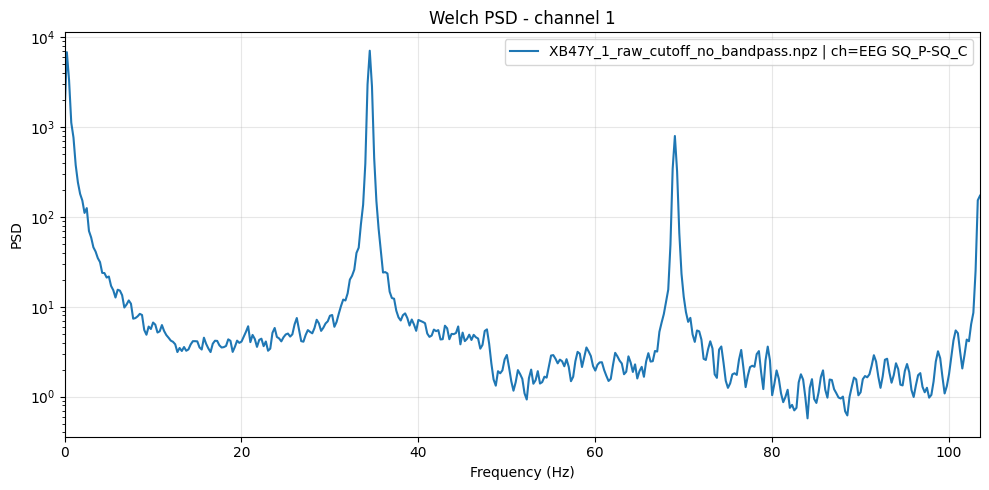


--- FILE 1 INFO ---
path: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/processed_no_bandpass/XB47Y_1_raw_cutoff_no_bandpass.npz
signal key: X
signal shape (C, N): (2, 28566)
fs: 207.03105465824683
channel names: ['EEG SQ_D-SQ_C' 'EEG SQ_P-SQ_C']
nperseg: 828
noverlap: 414
nyquist: 103.51552732912342


{'file1': {'path': '/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/processed_no_bandpass/XB47Y_1_raw_cutoff_no_bandpass.npz'},
 'file2': None}

In [19]:
# Before band pass
npz_path_process = "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/processed_no_bandpass/XB47Y_1_raw_cutoff_no_bandpass.npz"

TEEG_PR.plot_psd_from_npz_1_12(
    npz_path_1= npz_path_process,
    channel=1
)

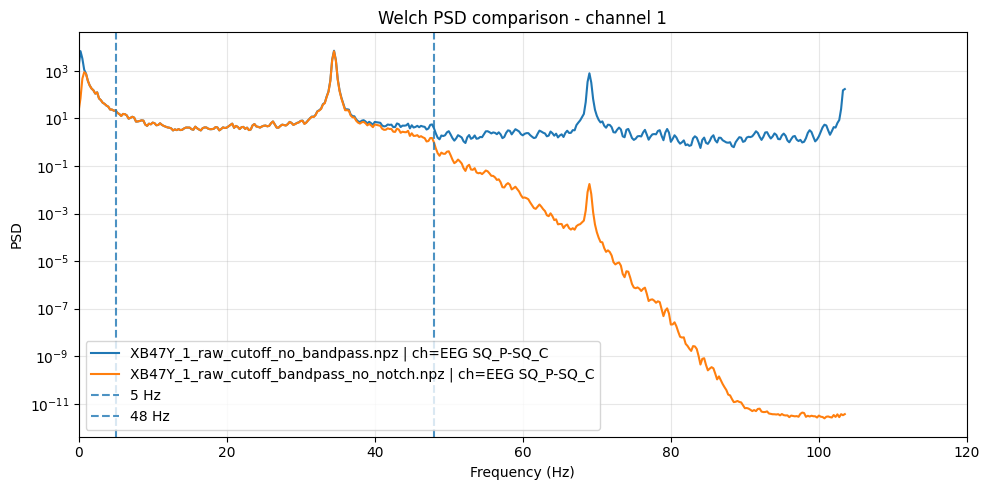


--- FILE 1 INFO ---
path: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/processed_no_bandpass/XB47Y_1_raw_cutoff_no_bandpass.npz
signal key: X
signal shape (C, N): (2, 28566)
fs: 207.03105465824683
nperseg: 828
noverlap: 414
nyquist: 103.51552732912342

--- FILE 2 INFO ---
path: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/processed_bandpass_no_notch/XB47Y_1_raw_cutoff_bandpass_no_notch.npz
signal key: X
signal shape (C, N): (2, 28566)
fs: 207.03105465824683
nperseg: 828
noverlap: 414
nyquist: 103.51552732912342


In [24]:
results = plot_psd_two_npz_with_lines(
    npz_path_1="/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/processed_no_bandpass/XB47Y_1_raw_cutoff_no_bandpass.npz",
    npz_path_2="/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/processed_bandpass_no_notch/XB47Y_1_raw_cutoff_bandpass_no_notch.npz",
    channel=1,
    xlim=(0, 120),
    use_semilogy=True,
    strict_checks=False
)

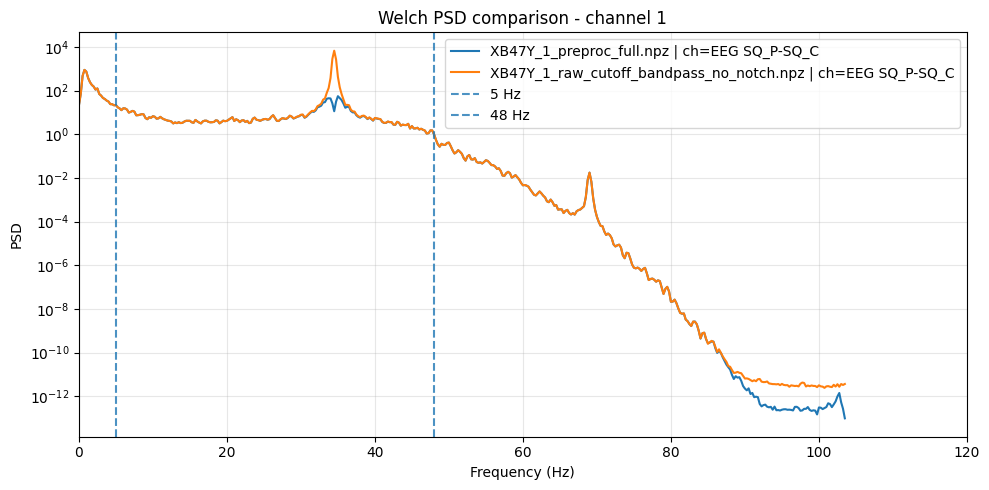


--- FILE 1 INFO ---
path: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/XB47Y/Pre_processing/XB47Y_IN-XB47Y_AMP200_BP0p5-48Hz_NOTCH34p5Hz_NOZSCORE_20260504/npz/XB47Y_1_preproc_full.npz
signal key: X
signal shape (C, N): (2, 28566)
fs: 207.03105465824683
nperseg: 828
noverlap: 414
nyquist: 103.51552732912342

--- FILE 2 INFO ---
path: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/processed_bandpass_no_notch/XB47Y_1_raw_cutoff_bandpass_no_notch.npz
signal key: X
signal shape (C, N): (2, 28566)
fs: 207.03105465824683
nperseg: 828
noverlap: 414
nyquist: 103.51552732912342


In [25]:
results = plot_psd_two_npz_with_lines(
    npz_path_1="/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/XB47Y/Pre_processing/XB47Y_IN-XB47Y_AMP200_BP0p5-48Hz_NOTCH34p5Hz_NOZSCORE_20260504/npz/XB47Y_1_preproc_full.npz",
    npz_path_2="/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/data/Working/XB47Y/processed_bandpass_no_notch/XB47Y_1_raw_cutoff_bandpass_no_notch.npz",
    channel=1,
    xlim=(0, 120),
    use_semilogy=True,
    strict_checks=False
)

In [ ]:
# After only band pass and no notch

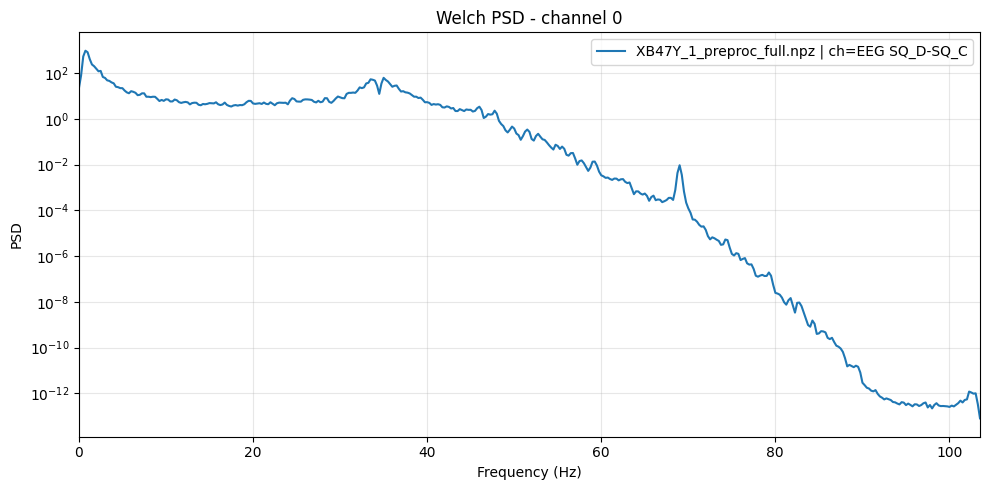


--- FILE 1 INFO ---
path: /home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/XB47Y/Pre_processing/XB47Y_IN-XB47Y_AMP200_BP0p5-48Hz_NOTCH34p5Hz_NOZSCORE_20260504/npz/XB47Y_1_preproc_full.npz
signal key: X
signal shape (C, N): (2, 28566)
fs: 207.03105465824683
channel names: ['EEG SQ_D-SQ_C' 'EEG SQ_P-SQ_C']
nperseg: 828
noverlap: 414
nyquist: 103.51552732912342


{'file1': {'path': '/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/XB47Y/Pre_processing/XB47Y_IN-XB47Y_AMP200_BP0p5-48Hz_NOTCH34p5Hz_NOZSCORE_20260504/npz/XB47Y_1_preproc_full.npz'},
 'file2': None}

In [5]:
# AFTER notch
npz_path_process = "/home/tperezsanchez/Tomas_PS_DissertationKCL2026/Main_project/results/XB47Y/Pre_processing/XB47Y_IN-XB47Y_AMP200_BP0p5-48Hz_NOTCH34p5Hz_NOZSCORE_20260504/npz/XB47Y_1_preproc_full.npz"

TEEG_PR.plot_psd_from_npz_1_12(
    npz_path_1= npz_path_process,
    channel=1
)

In [ ]:
# AFTER NOTCH
